[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/trim-filter-messages.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239435-lesson-4-trim-and-filter-messages)

# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_openai

In [1]:
import os
import dotenv as env

env.load_dotenv('../.env')

OPENROUTER_API_URL = os.getenv('OPENROUTER_API_URL')
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY')

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

We'll log to a project, `langchain-academy`. 

## Messages as state

First, let's define some messages.

In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


Recall we can pass them to a chat model.

In [41]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="gpt-4o-mini", 
    temperature=0,
    model_provider="openai",
    openai_api_key=OPENROUTER_API_KEY, 
    openai_api_base=OPENROUTER_API_URL
)

llm.invoke(messages)

AIMessage(content="Orcas, also known as killer whales (*Orcinus orca*), are highly adaptable marine mammals found in oceans all around the world. Here’s a breakdown of their habitats:\n\n### 1. **Global Distribution**\n* **Widespread Presence:** Orcas inhabit all of the world's oceans, from the Arctic and Antarctic regions to tropical seas. They are most commonly found in coastal and continental shelf areas.\n* **Preferred Regions:** They tend to favor colder waters, particularly in regions like:\n  * The **North Pacific Ocean** (e.g., around Alaska, British Columbia, and California)\n  * The **North Atlantic Ocean** (e.g., around Norway, Iceland, and the eastern coast of the United States)\n  * The **Southern Ocean** surrounding Antarctica.\n\n### 2. **Habitat Preferences**\n* **Coastal Areas:** Many orca populations are found in coastal waters, where they hunt for fish, seals, and other marine mammals. They are often seen near shorelines, fjords, and bays.\n* **Open Ocean:** Some orc

We can run our chat model in a simple graph with `MessagesState`.

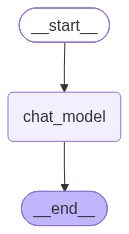

In [8]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Beyond large whales, marine mammals are a diverse group adapted to ocean life in very different ways. Scientists generally divide marine mammals into four main groups. 

Here are the other fascinating ocean mammals you should look into:

---

### 1. Pinnipeds (Seals, Sea Lions, and Walruses)
Pinnipeds are "fin-footed" mammals that split their time between feeding in the ocean and resting, mating, or giving birth on land or sea ice.

* **True Seals (Earless Seals):** 
  * *How they move:* They lack external ear flaps and move on land by undulating their bellies (like a caterpillar) because their hind flippers cann

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

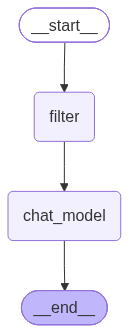

In [10]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Beyond whales, marine mammals are generally divided into a few distinct and fascinating groups. Here are the key ones you should explore:

---

### 1. **Pinnipeds (Seals, Sea Lions, and Walruses)**
These are "fin-footed" carnivores that split their time between the ocean (to hunt) and land or sea ice (to rest, mate, and give birth).

* **True Seals (Earless Seals):** Examples include Harbor seals, Elephant seals, and Leopard seals. They move on land by wriggling on their bellies and swim using their hind flippers.
  * *Fun research topic:* **Elephant seals**, which can dive over 5,000 feet deep and stay underwate

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

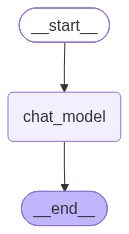

In [12]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [13]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [14]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Beyond whales, marine mammals are generally divided into a few distinct and fascinating groups. Here are the key ones you should explore:

---

### 1. **Pinnipeds (Seals, Sea Lions, and Walruses)**
These are "fin-footed" carnivores that split their time between the ocean (to hunt) and land or sea ice (to rest, mate, and give birth).

* **True Seals (Earless Seals):** Examples include Harbor seals, Elephant seals, and Leopa

In [15]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Beyond whales, marine mammals are generally divided into a few distinct and fascinating groups. Here are the key ones you should explore:

---

### 1. **Pinnipeds (Seals, Sea Lions, and Walruses)**
These are "fin-footed" carnivores that split their time between the ocean (to hunt) and land or sea ice (to rest, mate, and give birth).

* **True Seals (Earless Seals):** Examples include Harbor seals, Elephant seals, and Leopa

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

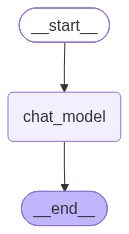

In [43]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
        state["messages"],
        max_tokens=100,
        strategy="last",
        token_counter=llm,
        allow_partial=False,
    )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [42]:
trim_messages(
    messages,
    max_tokens=100,
    strategy="last",
    token_counter=llm,
    include_system=True,
    allow_partial=False
)

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance', id='ccf38796-ba60-468e-a7b0-b4b0e9dd8498')]

In [44]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [47]:
from langchain_core.messages import BaseMessage


messages: BaseMessage = messages_out_trim['messages']

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Beyond whales, marine mammals are generally divided into a few distinct and fascinating groups. Here are the key ones you should explore:

---

### 1. **Pinnipeds (Seals, Sea Lions, and Walruses)**
These are "fin-footed" carnivores that split their time between the ocean (to hunt) and land or sea ice (to rest, mate, and give birth).

* **True Seals (Earless Seals):** Examples include Harbor seals, Elephant seals, and Leopa

Let's look at the LangSmith trace to see the model invocation:

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r